## CNN
The MNIST dataset is a large collection of handwritten digits. It’s widely regarded as a benchmark dataset for evaluating the performance of various image classification algorithms. The dataset contains 70,000 grayscale images of handwritten digits (0 to 9), with each image having a size of 28x28 pixels. The pixel values range from 0 to 255, where 0 represents black, 255 represents white, and the values in between represent various shades of gray.

In [19]:
import numpy as np
import matplotlib.pyplot as plt 
%matplotlib inline

In [20]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist

In [21]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [22]:
sample_set = x_train[0]

In [23]:
def calculate_target(img_shape, kernel_shape):
    row_size = img_shape[0] - kernel_shape[0] + 1
    col_size = img_shape[1] - kernel_shape[1] + 1
    if len(kernel_shape) == 3:
        feature_size = kernel_shape[2]
    else:
        feature_size = 1
    target = np.zeros((row_size , col_size, feature_size))
    
    return row_size, col_size, feature_size, target

def convolve(img, kernel):
    row_size, col_size, feature_size, CovImage = calculate_target(
        img.shape,
        kernel.shape
    )
    if feature_size == 1:
        kernel = kernel.reshape(kernel.shape[0], kernel.shape[1], 1)
        CovImage = CovImage.reshape(CovImage.shape[0], CovImage.shape[1], 1)
    for k in range(feature_size):
        for i in range(row_size):
            for j in range(col_size):
                CovImage[i,j,k] = (img[i:i+kernel.shape[0],j:j+kernel.shape[1]] * kernel[:, :, k]).sum()

    return CovImage


In [24]:
kersl = np.array([[0, 0, 0],
                   [0, 0, 1],
                   [0, 0, 0]])


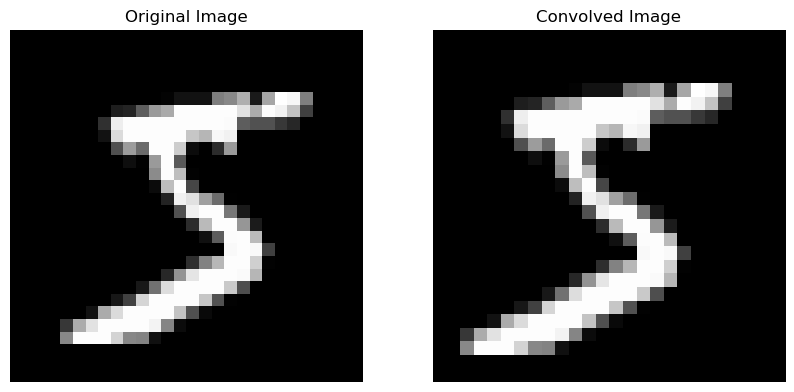

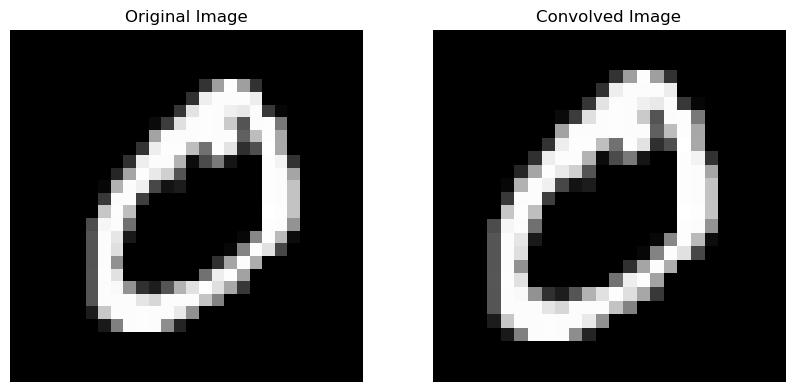

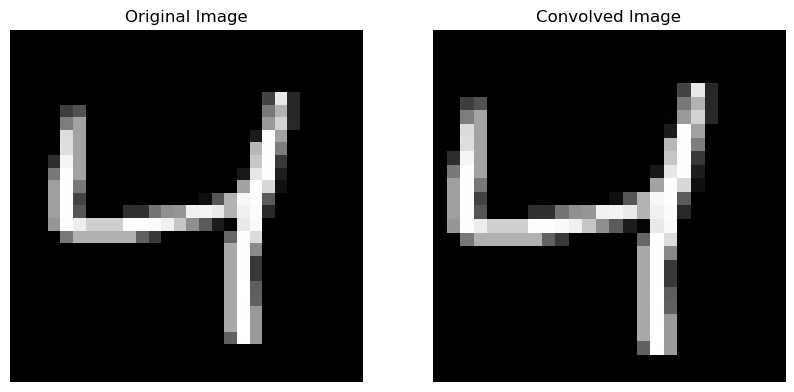

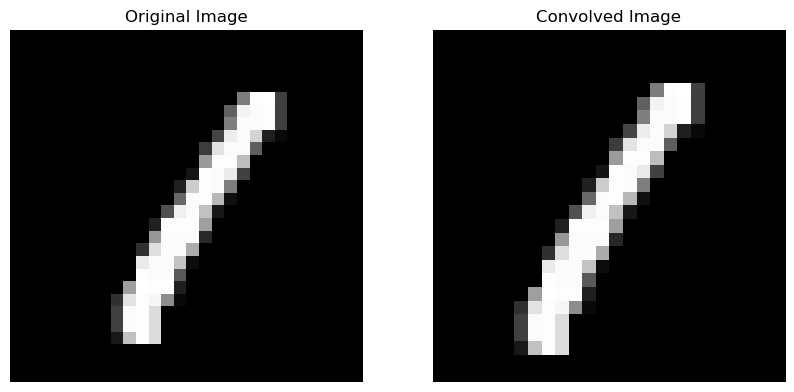

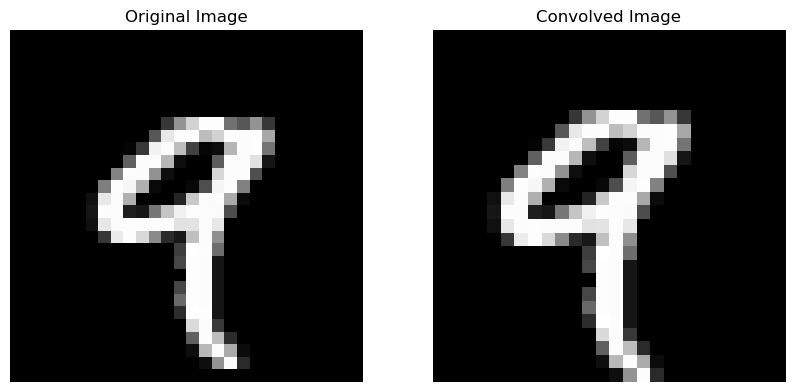

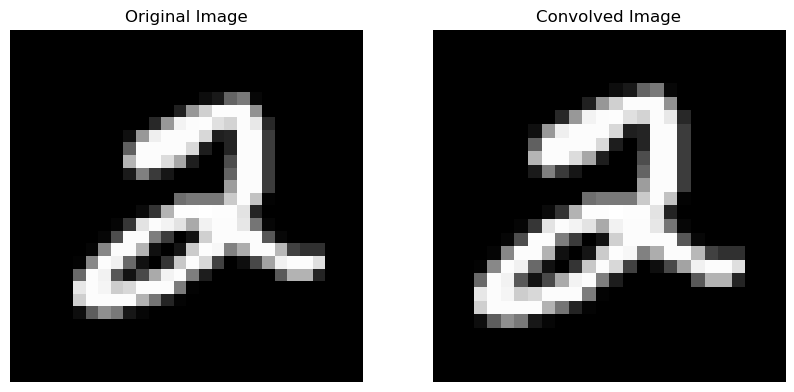

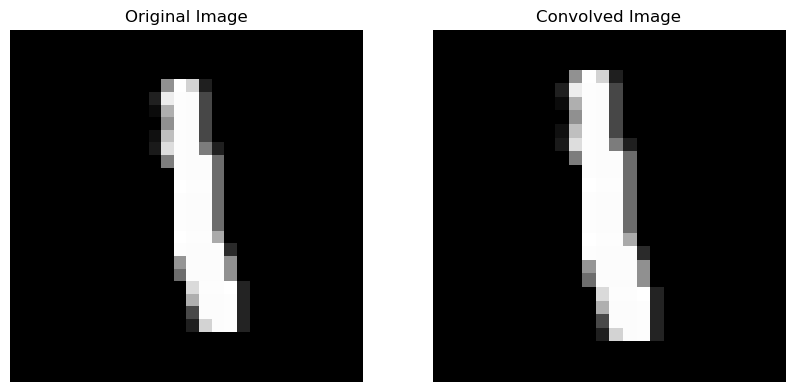

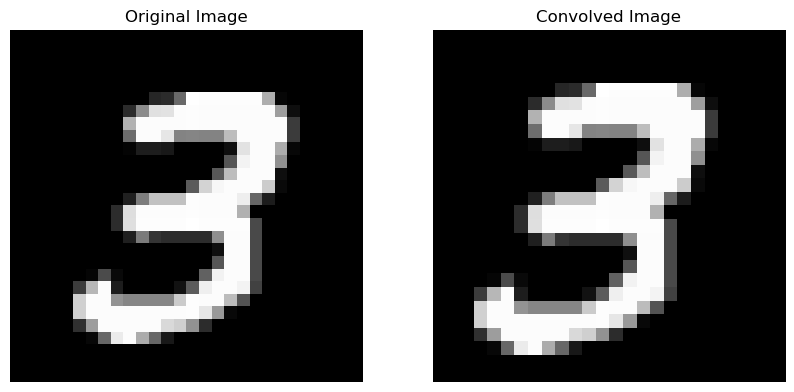

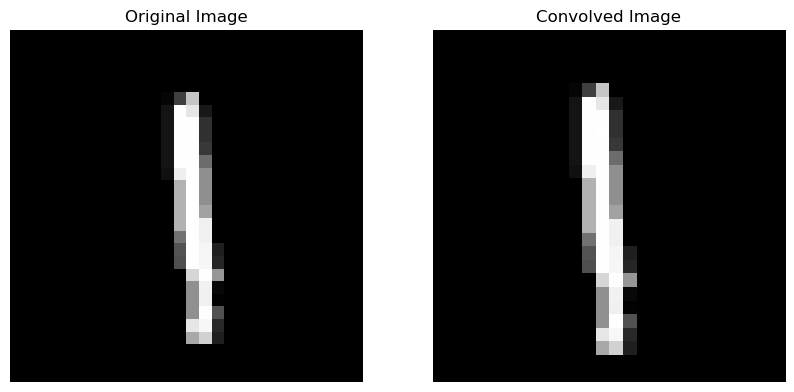

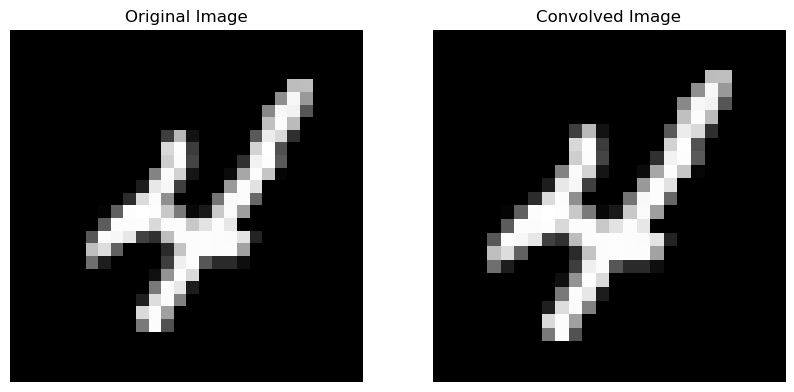

In [25]:
## compare show
for _ in x_train[:10]:
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(_, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')

    convolved_image = convolve(_, kersl)
    
    plt.subplot(1, 2, 2)
    plt.imshow(convolved_image, cmap='gray')
    plt.title('Convolved Image')
    plt.axis('off')

    plt.show()

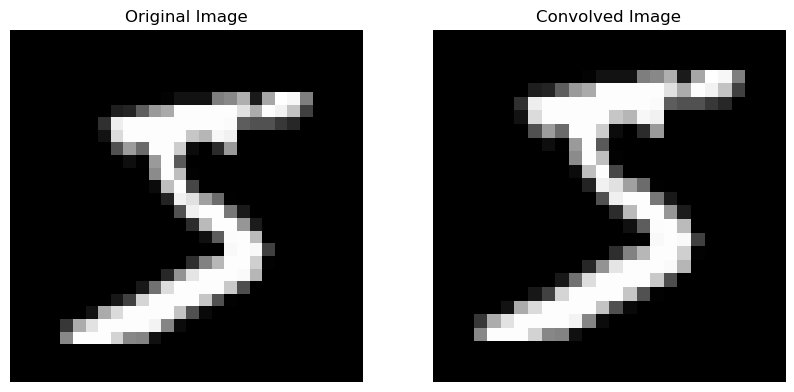

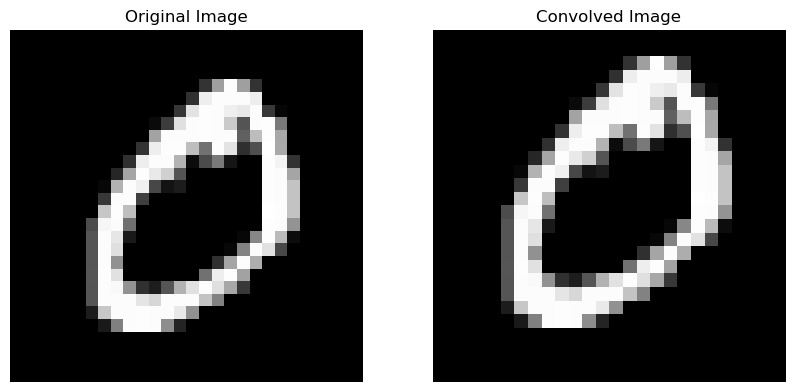

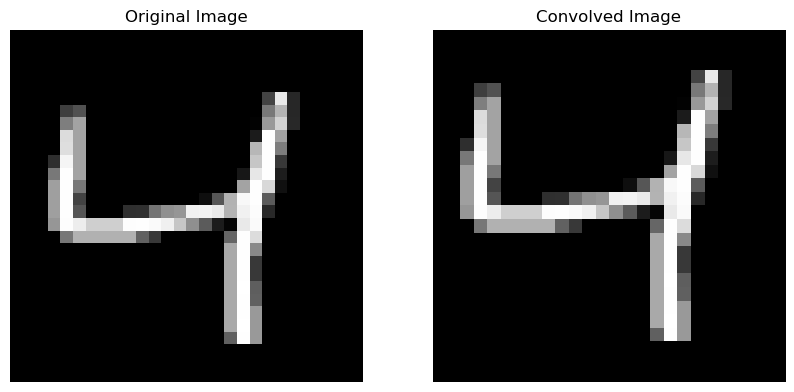

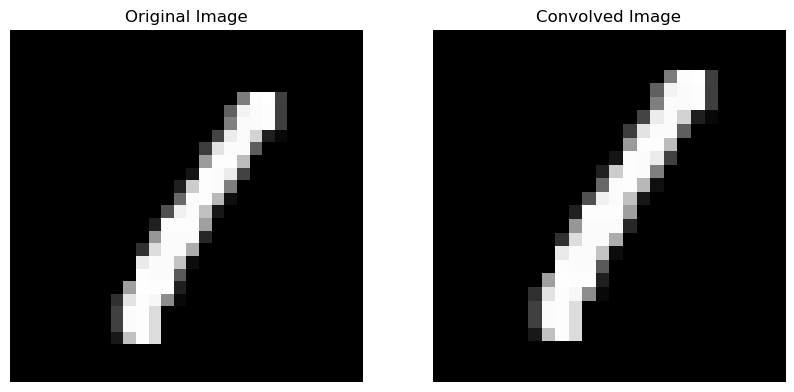

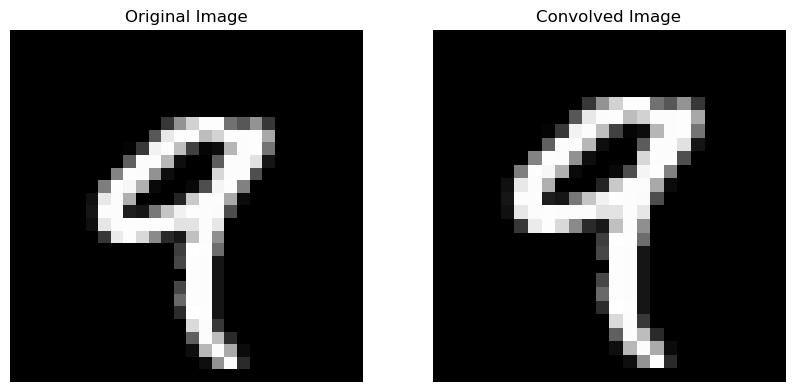

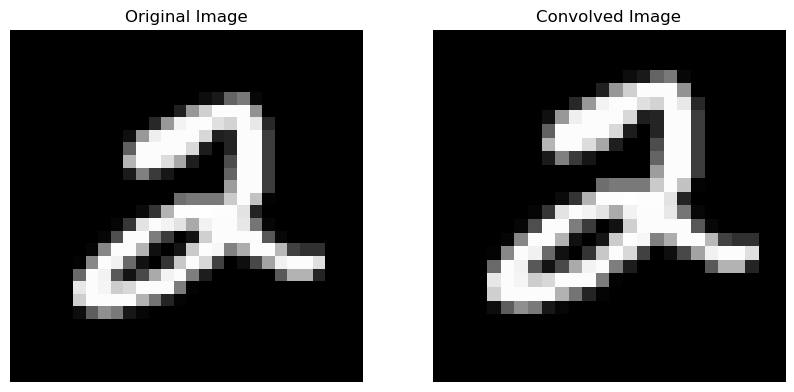

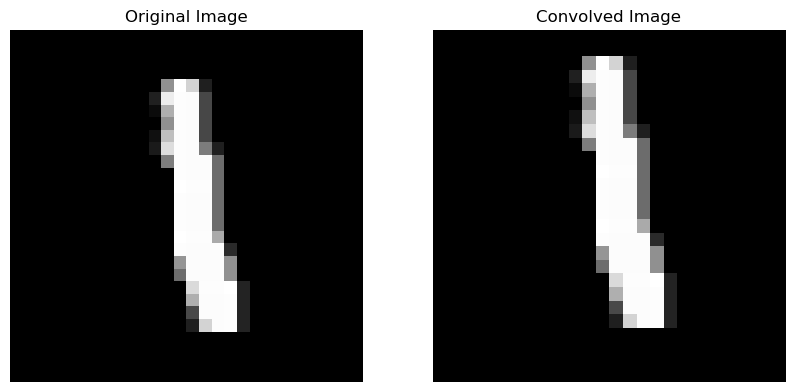

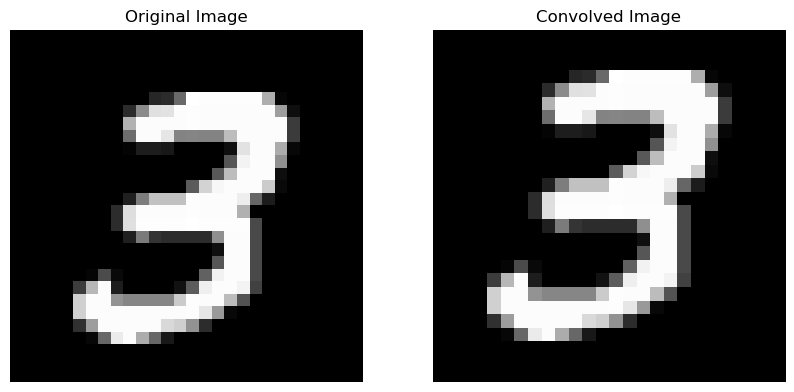

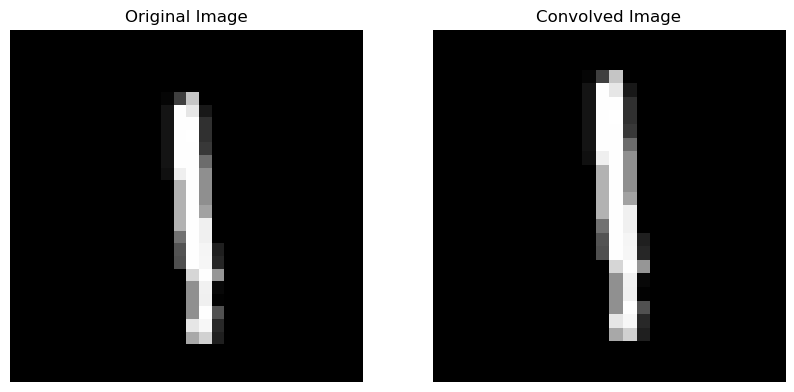

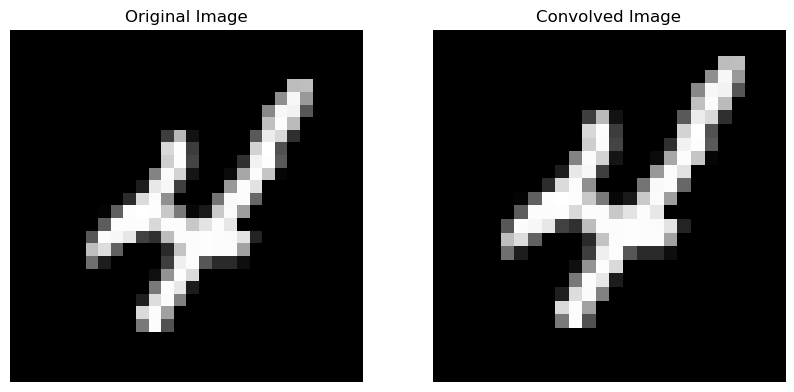

In [26]:
kerst = np.array([[0, 0, 0],
                   [0, 0, 0],
                   [0, 1, 0]])
## compare show
for _ in x_train[:10]:
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(_, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')

    convolved_image = convolve(_, kerst)
    
    plt.subplot(1, 2, 2)
    plt.imshow(convolved_image, cmap='gray')
    plt.title('Convolved Image')
    plt.axis('off')

    plt.show()

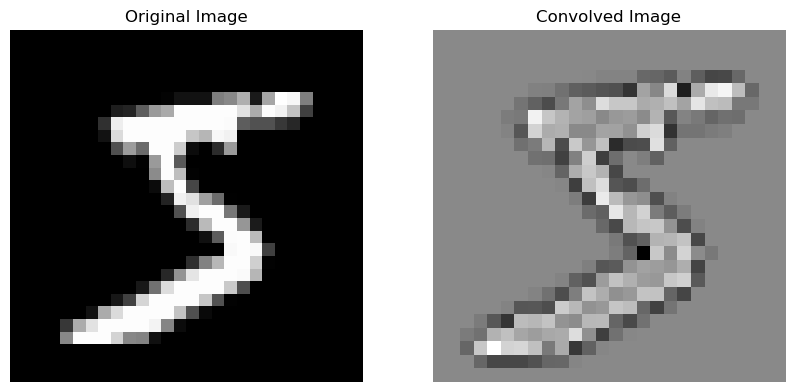

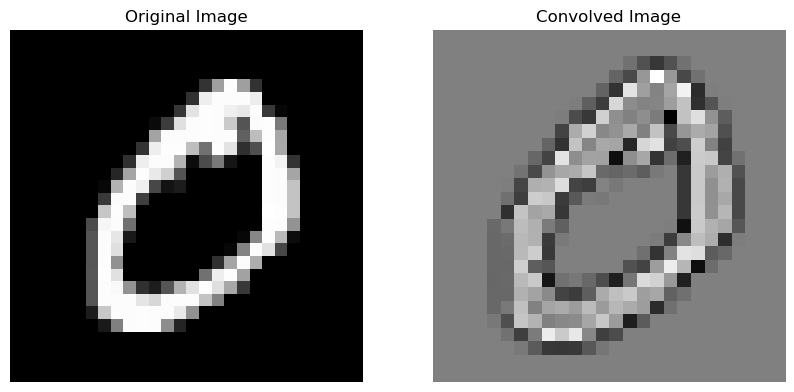

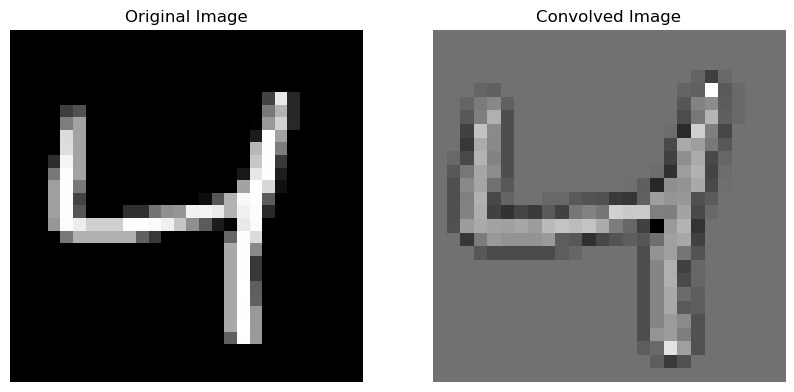

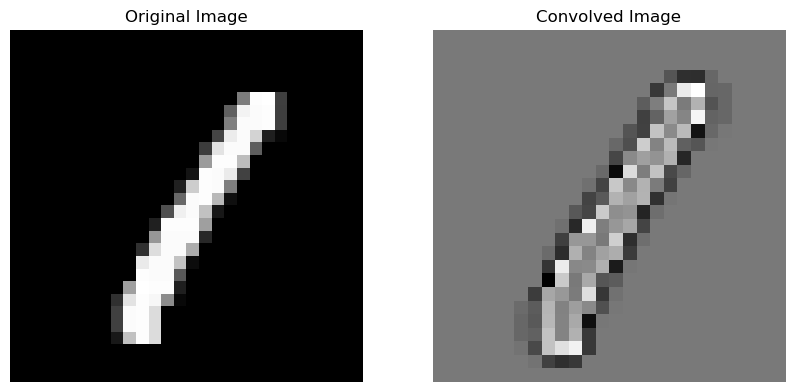

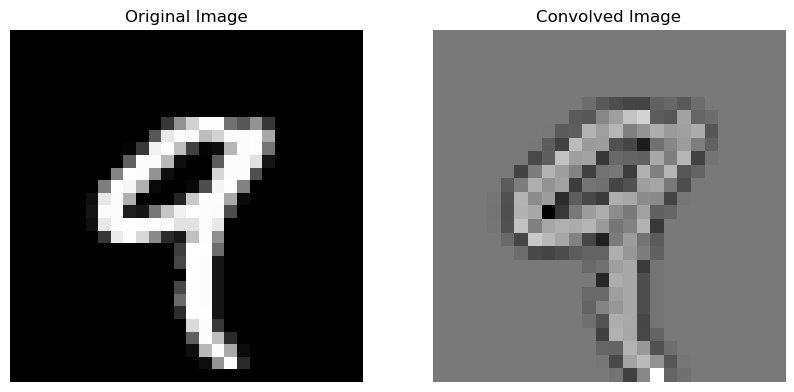

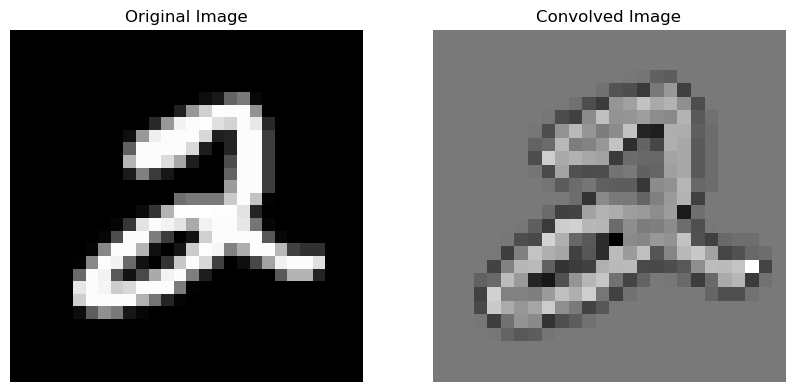

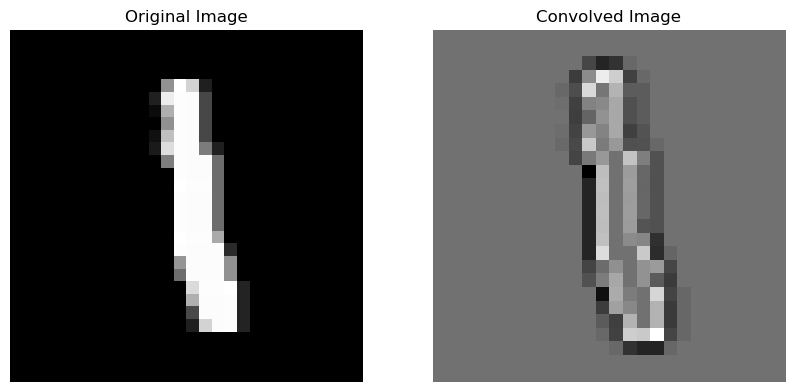

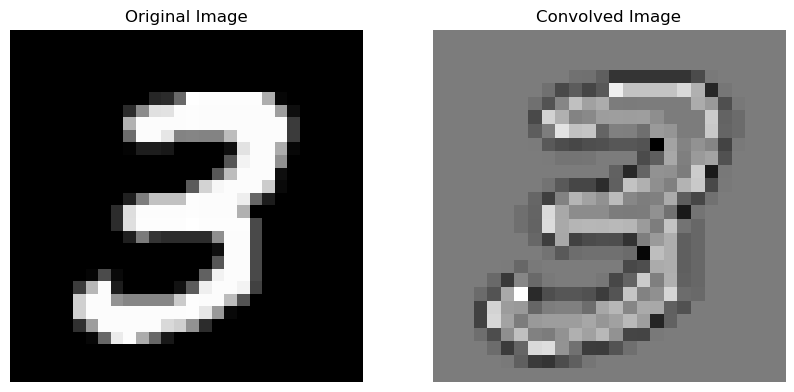

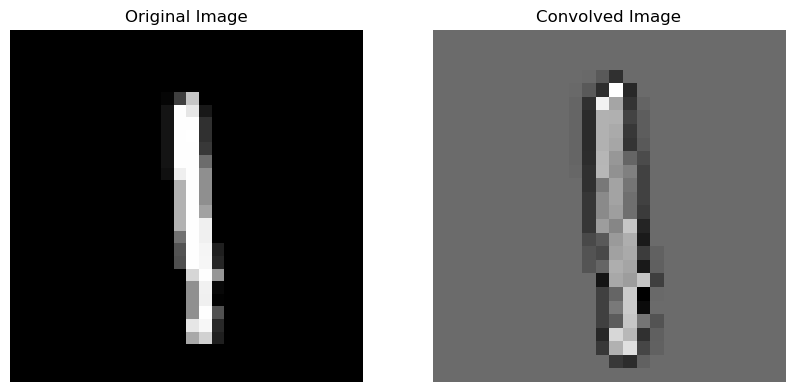

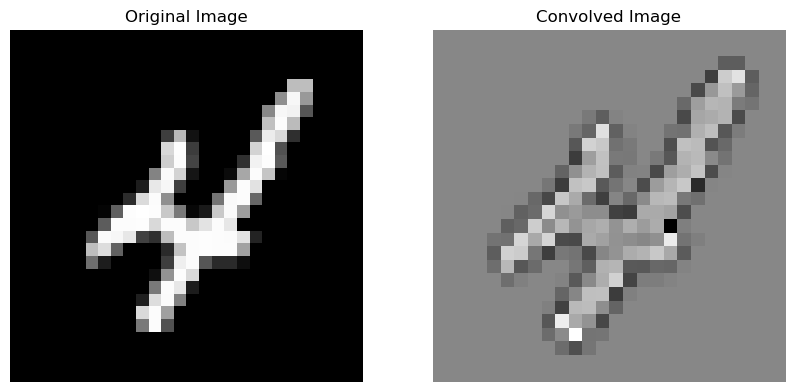

In [27]:
kerlap = np.array([[0, -2, 0],
                   [-2, 8, -2],
                   [0, -2, 0]])/2
for _ in x_train[:10]:
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(_, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')

    convolved_image = convolve(_, kerlap)
    
    plt.subplot(1, 2, 2)
    plt.imshow(convolved_image, cmap='gray')
    plt.title('Convolved Image')
    plt.axis('off')

    plt.show()

### Tensorflow version


Using Tensorflow to fit a CNN which performs 10 class classification, using the images in x_train to predict y_train and evaluate performace on the test data. 

In [ ]:
## Define the ResNet
def resblock(x, filters, kernel_size):
    shortcut = x
    x = tf.keras.layers.Conv2D(filters, (kernel_size, kernel_size), padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.Conv2D(filters, (kernel_size, kernel_size), padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Add()([shortcut, x])
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)

    return x


In [ ]:
# ## build a model with 2 hidden layers with cov2d
# inputs = tf.keras.Input(shape = (28, 28))
# x = tf.keras.layers.Reshape((28, 28, 1))(inputs)
# x = tf.keras.layers.Conv2D(32, (3, 3), padding='same')(x)
# x = tf.keras.layers.Activation('relu')(x)
# x = tf.keras.layers.BatchNormalization()(x)
# x = tf.keras.layers.MaxPooling2D((2, 2))(x)
# x = tf.keras.layers.Conv2D(64, (3, 3), padding='same')(x)
# x = tf.keras.layers.Activation('relu')(x)
# x = tf.keras.layers.BatchNormalization()(x)
# x = tf.keras.layers.MaxPooling2D((2, 2))(x)
# x = tf.keras.layers.Flatten()(x)
# x = tf.keras.layers.Dense(64)(x)
# outputs = tf.keras.layers.Dense(10, activation='softmax')(x)

# model = tf.keras.Model(inputs = inputs, outputs = outputs)

In [30]:
# opt = tf.keras.optimizers.Adam(learning_rate=0.001)
# model.compile(optimizer=opt, 
#               loss='sparse_categorical_crossentropy',
#               metrics = ['accuracy'])
# model.fit(x_train, y_train, batch_size=32, epochs=10, validation_data=(x_test, y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9569 - loss: 0.2379 - val_accuracy: 0.9824 - val_loss: 0.0840
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9824 - loss: 0.0783 - val_accuracy: 0.9739 - val_loss: 0.1011
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9860 - loss: 0.0513 - val_accuracy: 0.9869 - val_loss: 0.0478
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9881 - loss: 0.0419 - val_accuracy: 0.9843 - val_loss: 0.0541
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9903 - loss: 0.0305 - val_accuracy: 0.9889 - val_loss: 0.0402
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9912 - loss: 0.0283 - val_accuracy: 0.9885 - val_loss: 0.0437
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9930 - loss: 0.0225 - val_accuracy: 0.9864 - val_loss: 0.0527
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9938 -

In [32]:
fit_sample = tf.keras.Sequential([
    tf.keras.Input(shape = (28, 28)),
    tf.keras.layers.Reshape((28, 28, 1)),
    tf.keras.layers.Conv2D(8, (3, 3), padding='same'), ## numbers of filters is 8
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(8),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])
opt = tf.keras.optimizers.Adam(learning_rate=0.001)
fit_sample.compile(optimizer=opt, 
              loss='sparse_categorical_crossentropy',
              metrics = ['accuracy'])
fit_sample.fit(x_train, y_train, batch_size=32, epochs=2, validation_data=(x_test, y_test))

Epoch 1/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8857 - loss: 0.3746 - val_accuracy: 0.9602 - val_loss: 0.1320
Epoch 2/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9651 - loss: 0.1161 - val_accuracy: 0.9617 - val_loss: 0.1185


* The samplist model we get is just one hidden layer
* With Batch Norm and Maxpooling
* The accuracy for test data is 96%

The weights convoluted the image into 32 feature maps

In [41]:
layer_outputs = [layer.output for layer in fit_sample.layers]
layers_model = tf.keras.Model(inputs=fit_sample.inputs, outputs = layer_outputs)

layers_activated_outputs = layers_model.predict(x_test[1:2])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━

(array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]),
 array([-0.5,  0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5]),
 <BarContainer object of 10 artists>)

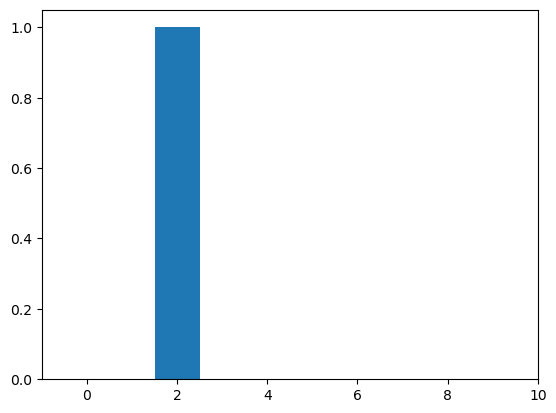

In [66]:
x_sample = x_test[1:2]## choose the first one
y_sample = y_test[1]
## predict on it many times, and create histograms for the probability that it belongs to each class 0-9 and discuss your findings.
y_pred = np.zeros((100, 10)) ## 100 times, 10 classes
# fir
for _ in range(100):
    y_pred[_] = fit_sample.predict(x_sample)
plt.hist(y_pred.argmax(axis=1), bins=np.arange(11)-0.5, density=True)

In [65]:
fit_sample.predict(x_sample)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


array([[4.4082192e-04, 1.1850472e-03, 9.9824440e-01, 1.3369448e-05,
        2.4183526e-06, 3.5700493e-10, 2.6457258e-08, 8.1007779e-12,
        1.1400003e-04, 2.2583988e-09]], dtype=float32)

In [68]:
## Example using in tf
import numpy as np
import tensorflow as tf
import tensorflow_probability as tfp
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing
import matplotlib.pyplot as plt
%matplotlib inline
tfd = tfp.distributions
tfpl = tfp.layers
import tf_keras


In [72]:
KLden = x_train.shape[0] ## number of data points, for scaling the KL divergence term
fit_sample_bnn_softmax = tf_keras.Sequential([
    tf_keras.layers.Input(shape=(28, 28)),
    tf_keras.layers.Reshape((28, 28, 1)),

    tf_keras.layers.Conv2D(8, (3, 3), padding='same'),
    tf_keras.layers.Activation('relu'),
    tf_keras.layers.BatchNormalization(),
    tf_keras.layers.MaxPooling2D((2, 2)),

    tf_keras.layers.Flatten(),

    tf_keras.layers.Dense(8),
    tf_keras.layers.Activation('relu'),

    tfpl.DenseReparameterization(
        10,
        kernel_prior_fn=tfpl.default_multivariate_normal_fn,
        kernel_posterior_fn=tfpl.default_mean_field_normal_fn(),
        kernel_divergence_fn=lambda q, p, _: tfd.kl_divergence(q, p) / KLden
    ),

    tf_keras.layers.Activation('softmax')
])

fit_sample_bnn_softmax.compile(
    optimizer=tf_keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/opt/miniconda3/envs/torch-env/lib/python3.12/site-packages/tensorflow_probability/python/layers/util.py:99: UserWarning: `layer.add_variable` is deprecated and will be removed in a future version. Please use the `layer.add_weight()` method instead.
  loc = add_variable_fn(
/opt/miniconda3/envs/torch-env/lib/python3.12/site-packages/tf_keras/src/initializers/initializers.py:121: UserWarning: The initializer RandomNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(
/opt/miniconda3/envs/torch-env/lib/python3.12/site-packages/tensorflow_probability/python/layers/util.py:109: UserWarning: `layer.add_variable` is deprecated and will be removed in a future version. Please use the `layer.add_weight()` method instead.
  untransformed_scale = add_variable_fn(


In [73]:

fit_sample_bnn_softmax.fit(x_train, y_train, batch_size=32, epochs=2, validation_data=(x_test, y_test))

Epoch 1/2
1875/1875 [==============================] - 5s 2ms/step - loss: 0.3506 - accuracy: 0.8857 - val_loss: 0.1321 - val_accuracy: 0.9610
Epoch 2/2
1875/1875 [==============================] - 4s 2ms/step - loss: 0.1136 - accuracy: 0.9669 - val_loss: 0.0999 - val_accuracy: 0.9709


1/1 [==============================] - 0s 6ms/step


(array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]),
 array([-0.5,  0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5]),
 <BarContainer object of 10 artists>)

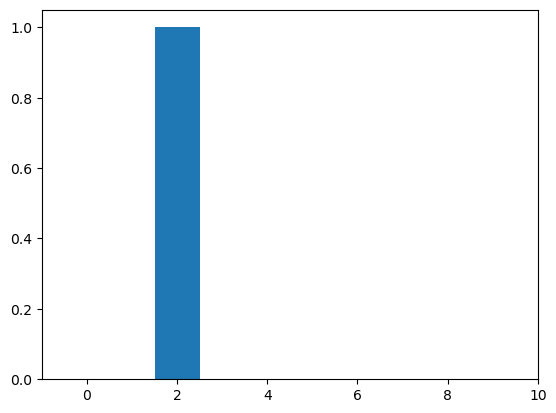

In [ ]:
x_sample = x_test[1:2]## choose the first one
y_sample = y_test[1]
## predict on it many times, and create histograms for the probability that it belongs to each class 0-9 and discuss your findings.
y_pred = np.zeros((100, 10)) ## 100 times, 10 classes
# fir
for _ in range(y_pred.shape[0]):
    y_pred[_] = fit_sample_bnn_softmax.predict(x_sample)
plt.hist(y_pred.argmax(axis=1), bins=np.arange(11)-0.5, density=True)

### Using torch

In [1]:
import numpy as np
import torch
import torch.functional as F
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms

In [4]:
batch_size = 64
num_epochs = 10
learning_rate = 0.01

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

In [35]:
train_dataset = datasets.MNIST(
    root='.', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(
    root='.', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size, shuffle = True)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=batch_size, shuffle = False)

In [46]:
## Define the Neural Network
class MNISTNet(nn.Module):
    def __init__(self):
        super(MNISTNet, self).__init__()
        self.conv2d = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3)
        self.relu = nn.ReLU()
        self.bn = nn.BatchNorm2d(8)
        self.pool = nn.MaxPool2d(2, 2)
        self.flatten = nn.Flatten()
        self.fc2 = nn.Linear(8*13*13, 64)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(64, 10)
    
    def forward(self, x):
        x = x.view(-1, 1, 28, 28)
        x = self.conv2d(x)
        x = self.relu(x)
        x = self.bn(x)
        x = self.pool(x)
        x = self.flatten(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x

In [55]:
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
torch_model = MNISTNet()
torch_model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(torch_model.parameters(), lr = learning_rate)

In [58]:
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, 1)
    return torch.sum(preds == labels).item() / len(labels)

def train(model, device, train_loader, criterion, optimizer, epoch):
    model.train()
    running_loss = 0.0
    running_acc = 0.0
    for i,(inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_acc += accuracy(outputs, labels)

        if (i + 1) % 200 == 0:
            print(f'Epoch [{epoch + 1}/{num_epochs}], Step [{i + 1}/{len(train_loader)}], Loss: {running_loss / 200:.4f}, Accuracy: {running_acc / 200:.4f}')
            running_loss = 0.0
            running_acc = 0.0

def test(model, device, test_loader, criterion):
    model.eval()
    test_loss = 0.0
    test_acc = 0.0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            test_acc += accuracy(outputs, labels)
    print(f'Test Loss: {test_loss / len(test_loader):.4f}, Test Accuracy: {test_acc / len(test_loader):.4f}')

Epoch [2/10], Step [200/938], Loss: 0.0208, Accuracy: 0.9949
Epoch [2/10], Step [400/938], Loss: 0.0332, Accuracy: 0.9927
Epoch [2/10], Step [600/938], Loss: 0.0419, Accuracy: 0.9909
Epoch [2/10], Step [800/938], Loss: 0.0340, Accuracy: 0.9910
Test Loss: 0.1229, Test Accuracy: 0.9824
Epoch [3/10], Step [200/938], Loss: 0.0162, Accuracy: 0.9950
Epoch [3/10], Step [400/938], Loss: 0.0383, Accuracy: 0.9924
Epoch [3/10], Step [600/938], Loss: 0.0285, Accuracy: 0.9925
Epoch [3/10], Step [800/938], Loss: 0.0336, Accuracy: 0.9913
Test Loss: 0.1081, Test Accuracy: 0.9834
Epoch [4/10], Step [200/938], Loss: 0.0192, Accuracy: 0.9952
Epoch [4/10], Step [400/938], Loss: 0.0346, Accuracy: 0.9929
Epoch [4/10], Step [600/938], Loss: 0.0506, Accuracy: 0.9908
Epoch [4/10], Step [800/938], Loss: 0.0399, Accuracy: 0.9923
Test Loss: 0.1092, Test Accuracy: 0.9842
Epoch [5/10], Step [200/938], Loss: 0.0218, Accuracy: 0.9948
Epoch [5/10], Step [400/938], Loss: 0.0304, Accuracy: 0.9935
Epoch [5/10], Step [600

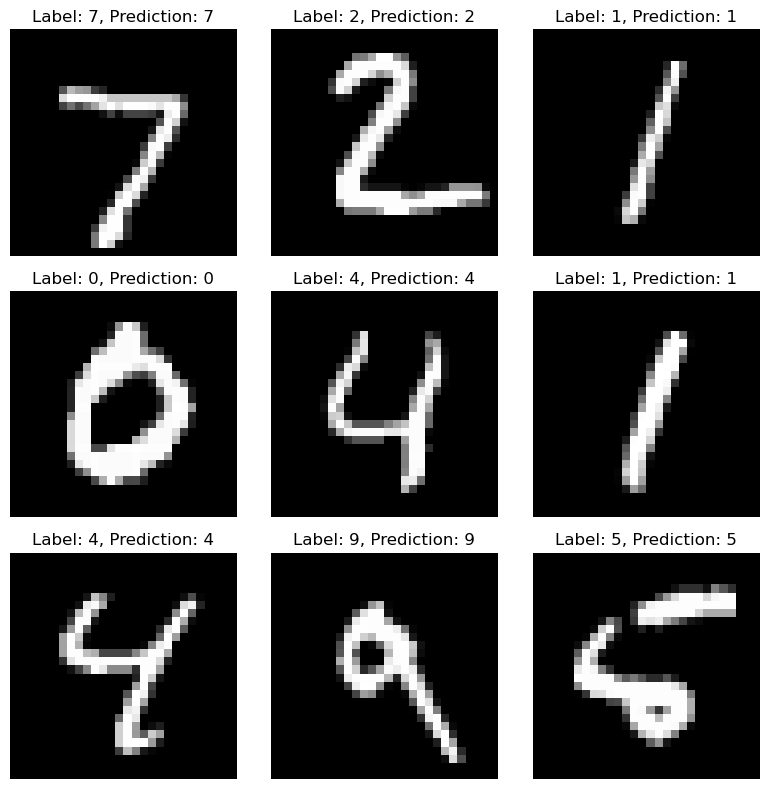

In [61]:
for epoch in range(1, num_epochs + 1):
    train(torch_model, device, train_loader, criterion, optimizer, epoch)
    test(torch_model, device, test_loader, criterion)

samples, labels = next(iter(test_loader))
samples = samples.to(device)
outputs = torch_model(samples)
_, preds = torch.max(outputs, 1)

samples = samples.cpu().numpy()
fig, axes = plt.subplots(3, 3, figsize=(8, 8))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(samples[i].squeeze(), cmap='gray')
    ax.set_title(f'Label: {labels[i]}, Prediction: {preds[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

## f {\color{red}(unfinished)}
Modify the model with Bayesian layer

## Problem 2


In [10]:
import gpflow
import gpflux
import tensorflow as tf
import numpy as np
import tf_keras
import matplotlib.pyplot as plt
%matplotlib inline


In [11]:
X= np.random.rand(100, 1) * 10
Y= np.sin(X) + np.random.normal(0, 0.1, (X.shape[0],1))

In [12]:
# Define the deep GP model
num_data, d_xim= X.shape
num_inducing= 20 # number of inducing points
inducing_variable= gpflow.inducing_variables.InducingPoints(
    np.linspace(X.min(),X.max(),num_inducing).reshape(-1, 1)
#X.reshape(-1,1)
)
kernel= gpflow.kernels.Exponential()
gp_layer= gpflux.layers.GPLayer(
    kernel, inducing_variable,
    num_data=num_data, num_latent_gps=1
)
likelihood_layer= gpflux.layers.LikelihoodLayer(
gpflow.likelihoods.Gaussian(0.1))

/opt/miniconda3/envs/torch-env/lib/python3.12/site-packages/gpflux/layers/gp_layer.py:175: UserWarning: Beware, no mean function was specified in the construction of the `GPLayer` so the default `gpflow.mean_functions.Identity` is being used. This mean function will only work if the input dimensionality matches the number of latent Gaussian processes in the layer.
  warnings.warn(
/opt/miniconda3/envs/torch-env/lib/python3.12/site-packages/gpflux/layers/gp_layer.py:198: UserWarning: Could not verify the compatibility of the `kernel`, `inducing_variable` and `mean_function`. We advise using `gpflux.helpers.construct_*` to create compatible kernels and inducing variables. As `num_latent_gps=1` has been specified explicitly, this will be used to create the `q_mu` and `q_sqrt` parameters.
  warnings.warn(
/var/folders/0w/f5zzkz9n0zx0sxqszqyxbkpw0000gn/T/ipykernel_54362/1642133755.py:13: DeprecationWarning: Call to deprecated class TrackableLayer. (GPflux's `TrackableLayer` was prior to TF2

In [13]:
single_layer_dgp= gpflux.models.DeepGP([gp_layer], likelihood_layer)
model= single_layer_dgp.as_training_model()
model.compile(tf_keras.optimizers.Adam(0.01))
model.fit({"inputs": X, "targets": Y},
epochs=int(1000), verbose=0)

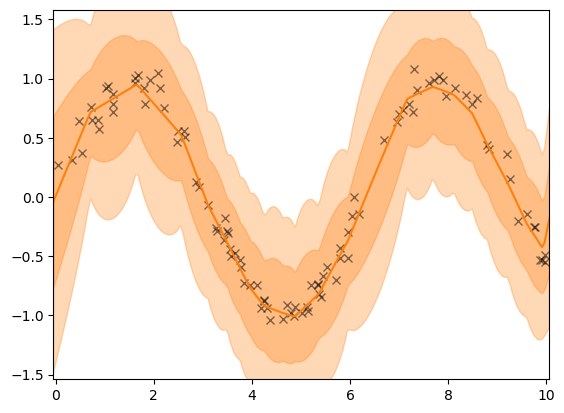

In [14]:
X_MARGIN, Y_MARGIN= 0.1, 0.5
fig, ax= plt.subplots()
num_data_seq= 200
X_seq= np.linspace(X.min()- X_MARGIN,
                    X.max() + X_MARGIN,
                    num_data_seq).reshape(-1, 1)
model= single_layer_dgp.as_prediction_model()
out = model(X_seq)
mu = out.y_mean.numpy().squeeze()
var = out.y_var.numpy().squeeze()
X_test= X_seq.squeeze()
# dual bands
for i in [1, 2]:
    lower= mu- i * np.sqrt(var)
    upper= mu + i * np.sqrt(var)
    ax.fill_between(X_test, lower, upper,
                    color="C1", alpha=0.3)
ax.set_ylim(Y.min()- Y_MARGIN, Y.max() + Y_MARGIN)
ax.set_xlim(X.min()- X_MARGIN, X.max() + X_MARGIN)
ax.plot(X, Y, "kx", alpha=0.5)
ax.plot(X_test, mu, "C1")

In [16]:
# Define the deep GP model with two layers
num_data, d_xim= X.shape
num_inducing= 20 # number of inducing points
Q = 1
inducing_variable= gpflow.inducing_variables.InducingPoints(
    np.linspace(X.min(),X.max(),num_inducing).reshape(-1, 1)
#X.reshape(-1,1)
)
kernel= gpflow.kernels.Exponential()
gp_layer= gpflux.layers.GPLayer(
    kernel, inducing_variable,
    num_data=num_data, num_latent_gps=Q,
    mean_function=gpflow.mean_functions.Zero(),
)


## layer 2
kernel = gpflow.kernels.Exponential()
inducing_variable= gpflow.inducing_variables.InducingPoints(
    np.random.randn(num_inducing, Q)
#X.reshape(-1,1)
)
gp_layer2= gpflux.layers.GPLayer(
    kernel, inducing_variable,
    num_data=num_data, num_latent_gps=1, ## num latent gps should match the input of next layer
    mean_function=gpflow.mean_functions.Identity() if Q == 1 else gpflow.mean_functions.Zero()
)
likelihood_layer= gpflux.layers.LikelihoodLayer(
    gpflow.likelihoods.Gaussian(0.1))

/opt/miniconda3/envs/torch-env/lib/python3.12/site-packages/gpflux/layers/gp_layer.py:198: UserWarning: Could not verify the compatibility of the `kernel`, `inducing_variable` and `mean_function`. We advise using `gpflux.helpers.construct_*` to create compatible kernels and inducing variables. As `num_latent_gps=1` has been specified explicitly, this will be used to create the `q_mu` and `q_sqrt` parameters.
  warnings.warn(
/var/folders/0w/f5zzkz9n0zx0sxqszqyxbkpw0000gn/T/ipykernel_54362/2176540297.py:28: DeprecationWarning: Call to deprecated class TrackableLayer. (GPflux's `TrackableLayer` was prior to TF2.5 used to collect GPflow variables in subclassed layers. As of TF 2.5, `tf.Module` supports this natively and there is no need for `TrackableLayer` anymore. It will be removed in GPflux version `1.0.0`.)
  likelihood_layer= gpflux.layers.LikelihoodLayer(


In [17]:
double_layer_dgp= gpflux.models.DeepGP([gp_layer, gp_layer2], likelihood_layer)
model2= double_layer_dgp.as_training_model()
model2.compile(tf_keras.optimizers.Adam(0.01))
model2.fit({"inputs": X, "targets": Y},
epochs=int(1000), verbose=0)

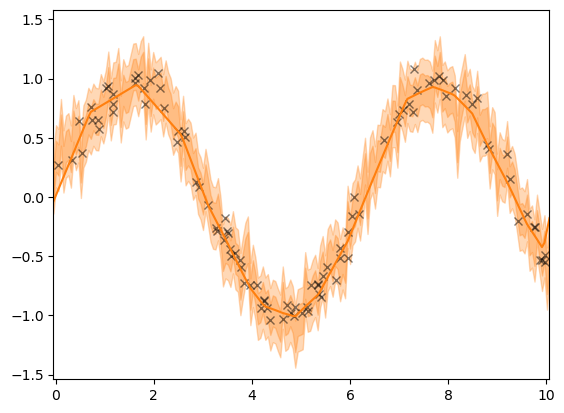

In [18]:
X_MARGIN, Y_MARGIN= 0.1, 0.5
fig, ax= plt.subplots()
num_data_seq= 200
X_seq= np.linspace(X.min()- X_MARGIN,
                    X.max() + X_MARGIN,
                    num_data_seq).reshape(-1, 1)
model2= double_layer_dgp.as_prediction_model()
out2 = model2(X_seq)
mu2 = out2.y_mean.numpy().squeeze()
var2 = out2.y_var.numpy().squeeze()
X_test= X_seq.squeeze()
# dual bands
for i in [1, 2]:
    lower= mu2 - i * np.sqrt(var2)
    upper= mu2 + i * np.sqrt(var2)
    ax.fill_between(X_test, lower, upper,
                    color="C1", alpha=0.3)
ax.set_ylim(Y.min()- Y_MARGIN, Y.max() + Y_MARGIN)
ax.set_xlim(X.min()- X_MARGIN, X.max() + X_MARGIN)
ax.plot(X, Y, "kx", alpha=0.5)
ax.plot(X_test, mu, "C1")